# Algorithms

This section introduces algorithm foundations using a simple input-process-output model and more.

## What Is an Algorithm?

In short, an algorithm is a **finite**, **ordered set of steps** that transforms **input** into **output**. A useful mental model for algorithm therefore is:
- **Input**: data provided to solve a problem
- **Process**: the steps that operate on the data
- **Output**: the result produced by the steps

A useful everyday analogy is a **recipe**: it specifies ingredients (inputs), a sequence of steps (instructions), and produces a dish (output). Like a recipe, an algorithm must eventually stop — it cannot run forever.

For example, an algorithm can be designed to look through an array (in general sense) to find the largest value in an array; in this case, a Python `list`. Here we are pretending that the `max()` function does not exist. So, for the example, let's say we want to go through the values in the array one by one. Check if the current value is the highest so far, and if it is, store it, then keep going until the end of the array. After looking at all the values, the stored value will be the highest of all values in the array.

A sketchy algorithm of this process as we just described may look like:

1. Go through the elements and get the values in the array one by one.
2. Check if the current value is the highest so far, and if it is, store it.
3. After looking at all the values, the stored value will be the highest of all values in the array.

:::{admonition} **Why Algorithms in Python?**

So by now you are probably thinking: Since we have many built-in methods (`max()` in this case) that serve as algorithms already, why do we still need to learn algorithms in Python? Here's why:

**Built-in Algorithms**:
Built-in methods like `max()`, `sorted()`, and `sum()` are convenient, but they are not a replacement for understanding algorithms. These methods are pre-implemented algorithms. Knowing how they work under the hood helps you understand their time and space complexity and recognize when they may be suboptimal or fail entirely. For example, `max(my_list)` still scans every element at $O(n)$ and it does not magically run faster just because Python provides it.

**Problem Coverage**:
Python built-ins do not cover all problem scenarios. Real-world challenges such as finding the shortest path in a network, scheduling tasks under constraints, recommending similar users, or detecting fraud patterns have no ready-made Python method. Solving them requires you to design and reason about algorithms from the ground up.

**Algorithmic Thinking**:
Even when built-ins exist, algorithmic thinking determines whether you can use them correctly and efficiently. Consider the difference between checking membership in a list versus a set: both work, but one runs in $O(n)$ and the other in $O(1)$. Without understanding the underlying algorithms, you cannot make that distinction, which matters enormously at scale. Similarly, calling `max()` inside a loop without realizing it re-scans the entire list each iteration can silently turn an $O(n)$ problem into an $O(n^2)$ one.

**Problem-Solving**:
Finally, algorithms are the foundation of problem-solving and computational thinking. Built-in methods are tools, and algorithmic knowledge is what tells you which tool to use, why it works, what its limits are, and what to do when no tool exists. This is why most technical interviews include algorithm questions.

Overall, understanding algorithms therefore means understanding what those tools are actually doing, when they are fast or slow, and what to do when no built-in exists for your problem.
:::

With the algorithm formulated, you may implement the algorithm in a specific programming language such as Python:

In [3]:
def max_value(nums):            ### input the array
    if not nums:                ### If the list is empty, return None
        return None             ### a "guard clause" to handle empty lists

    current_max = nums[0]       ### Initialize current_max to the first element of the list
    for x in nums[1:]:          ### Iterate through the list starting from the second element
        if x > current_max:     ### If the current element is greater than current_max, update current_max
            current_max = x
    return current_max          ### Return the maximum value found in the list

sample = [12, 4, 19, 7, 3]
print('input :', sample)
print('output:', max_value(sample))

input : [12, 4, 19, 7, 3]
output: 19


And this is probably how the Python `max()` function is defined. To make sure, the [Python Standard Library] has a [description](https://docs.python.org/3/library/functions.html#max) of the `max()` function and the implementation is in `C` and can be found at [github](https://github.com/python/cpython/blob/main/Python/bltinmodule.c#L2166). A emulation of that [implementation in Python](https://github.com/python/cpython/blob/main/Python/bltinmodule.c#L2166) looks like this below (partial code). As you can see, the code are very comparable. 

```python
def mymax_backend(      ### T is a generic type; works with any comparable type (int, str, etc.)  
    first_value: T,     ### The first value to compare against (the "current largest")      
    it: Iterator[T],    ### The remaining elements as an iterator 
    key: Optional[Callable[[T], Any]],
) -> T:
    largest = first_value
    if key is None:
        for x in it:
            if x > largest:
                largest = x
        return largest
    largest_key = key(largest)
    for x in it:
        kx = key(x)
        if kx > largest_key:
            largest = x
            largest_key = kx
    return largest
```

However, you probably have noticed that the algorithm is really too sketchy to design both algorithms and we need something more elaborative.

### Properties of an Algorithm

According [Donald Knuth](https://en.wikipedia.org/wiki/Donald_Knuth) in *The Art of Computer Programming*, an algorithm has certain properties:

- **Input**: An algorithm will starts its initial state, which may be expressed as the zero or more input values given before the algorithm stars.
- **Output**: An algorithm will produce zero or more outputs in relation to the inputs.
- **Finiteness** steps: An algorithm must start and stop with the rules the algorithm applies concluded. It cannot run forever — every algorithm must have a clear termination condition. 
- **Definiteness**: Each instruction in an algorithm must be precise and unambiguous; they can not be open to interpretations. Every step must be clear enough that anyone or any machine can follow it without interpretation. For example, "iterate a bunch of times" is not well-defined; the number of times must be precisely expressed.
- **Effectiveness**: The steps an algorithm takes must be sufficiently simple that they could be expressed; these steps must make sense for the quantities used.

You may also be concerned about some issues about algorithms such as: 
- Algorithms are not tied to any specific programming language. They describe what to do, not how a particular language does it.
- Given the same input, an algorithm always produces the same output; this property is called [**determinism**](https://en.wikipedia.org/wiki/Deterministic_algorithm). 


In [ ]:
### Exercise: Find the Minimum Value
#   1. Write a function `find_min(nums)` that returns the minimum value
#      in a list WITHOUT using Python's built-in min() function.
#   2. Your algorithm should work for any non-empty list of numbers.
#   3. Test with: find_min([5, 2, 8, 1, 9, 3])  -> 1
### Your code starts here.



### Your code ends here.

In [ ]:
### Solution
def find_min(nums):
    result = nums[0]           # sequence: initialize result
    for n in nums[1:]:         # repetition: visit each element
        if n < result:         # decision: is this smaller?
            result = n         # sequence: update result
    return result

print(find_min([5, 2, 8, 1, 9, 3]))   # Expected: 1
print(find_min([10, 10, 10]))          # Expected: 10
print(find_min([-3, 0, 5]))            # Expected: -3

## Implementing Algorithms

### The Design Process 

Now, looking at the `max_value()` example, there is a gap between having an algorithm figured out and having a piece of code to run and test the algorithm for **correctness** and **efficiency**. To jump from a sketchy algorithm to code may not be as easy as you want it to be as the steps are not "**well-defined**". Therefore, before implementing the algorithm using an actual programming language, it is usually smart to first write the algorithm as a step-by-step procedure.

So, before coding, you might want to use a design checklist like this:

1. Define **input** types and **output** format.
2. Write **step-by-step** **logic** in plain language.
3. Choose **data structures** that support the operations you need.
4. Test **edge cases** first (empty input, single item, duplicates, min/max, out of bound (0, -1, ...), etc).
5. Measure **performance** only after correctness is confirmed.

For the design of the algorithm, if you can write down the algorithm in something between human language and programming language, the algorithm will be easier to implement later because we avoid drowning in all the details of the programming language syntax. The `max_value()` function algorithm can look like this:

1. Create a variable `maxVal` and set it equal to the first value of the array. (**Variable**)
2. Go through every element in the array. (**Iteration**)
3. If the current element has a higher value than `maxVal`, update `maxVal` to this value. (**Update**)
4. After looking at all the elements in the array, the `maxVal` variable now contains the highest value.

In addition, you may choose to express this procedure in **pseudo code**, which should further define the steps of an algorithm.

```
Variable 'maxVal' = array[0]
For each element in the array
    If current element > maxVal
        maxVal = current element
```

### Control Patterns

In computer science, algorithms are evaluated on two key dimensions:

- **Correctness**: does it produce the right answer for all valid inputs, 
  including edge cases?
- **Efficiency**: how much **time** and **memory** does it consume as the 
  input grows? This is formalized through complexity analysis, commonly 
  expressed using Big $O$ notation such as $O(n)$ or $O(n^2)$.

After we are able to obtain correctness, our attention shifts to efficiency. To achieve efficiency, the design involves decisions about data structures and performance measurement. While going through these steps of the checklist, you want to pay attention to the three **control patterns** that most algorithms use to achieve better efficiency:

- **Sequence**: These steps run in order, one after another, with no branching or looping. This is the simplest pattern: each line executes exactly once, in the order it appears. For example, initializing a variable and then returning it are two sequential steps.

- **Decision**: choose different paths based on a condition (`if` / `elif` / `else`). Decisions let an algorithm respond differently to different inputs. For example, returning `None` for an empty list (guard clause) or assigning a letter grade based on a score are both decisions.

- **Repetition**: repeat a block of work for each item in a collection, or until a condition is met (`for`, `while`). Repetition lets an algorithm scale to any input size without duplicating code. For example, scanning every element in a list to find the maximum value uses repetition.

These three building blocks are enough to express the logic of virtually any algorithm. In practice, most algorithms layer all three: **repetition** drives the overall traversal, **decisions** handle special cases inside, and **sequence** connects each step in the right order.


Observe the following code and see the three building blocks of algorithm.

In [4]:
def classify_scores(scores):
    labels = []
    for s in scores:                      # repetition
        if s >= 90:                       # decision
            labels.append('A')
        elif s >= 80:
            labels.append('B')
        else:
            labels.append('C')
    return labels                         # sequence (line #2, 3, 10) ends with output

print(classify_scores([95, 81, 72, 90]))

['A', 'B', 'C', 'A']


Another example for observing the three building blocks of algorithm.

In [5]:
def summarize_orders(orders, discount_threshold=100):
    total_revenue = 0                           ### sequence: initialize output
    discounted_count = 0                        ### sequence: initialize counter

    for order in orders:                        ### repetition: visit every order
        amount = order['amount']

        if amount >= discount_threshold:        ### decision: qualify for discount?
            amount *= 0.9                       ### sequence: apply 10% discount
            discounted_count += 1               ### sequence: track how many

        total_revenue += amount                 ### sequence: accumulate

    return total_revenue, discounted_count      ### sequence: produce output

In [ ]:
### Exercise: Count Passing Scores
#   1. Write a function `count_passing(scores)` that returns the count of
#      scores that are 60 or above.
#   2. Your function must use all three control patterns:
#      sequence, selection (if), and repetition (for).
#   3. Test with: count_passing([45, 72, 60, 88, 55])  -> 3
### Your code starts here.



### Your code ends here.

In [ ]:
### Solution
def count_passing(scores):
    count = 0                  # sequence: initialize counter
    for s in scores:           # repetition: visit each score
        if s >= 60:            # decision: is the score passing?
            count += 1         # sequence: increment counter
    return count

print(count_passing([45, 72, 60, 88, 55]))  # Expected: 3
print(count_passing([30, 40, 50]))           # Expected: 0
print(count_passing([100, 90, 80]))          # Expected: 3

## Complexity and Big O

When evaluating an algorithm, correctness always comes first: the algorithm must produce the right answer for all valid inputs, including edge cases, before efficiency is even worth considering. A fast algorithm that gives wrong answers is not useful.

Once correctness is established, efficiency becomes the next concern. **Big $O$ notation** is the standard way to describe how an algorithm's runtime (or memory usage) grows as the input size $n$ increases. It captures the shape of the growth -- not the exact number of operations, but whether the algorithm scales **linearly**, **logarithmically**, **quadratically**, and so on. This allows you to compare algorithms independent of hardware or implementation details.

### Complexity

In algorithm analysis, Big $O$ notation is used to express the concept of **complexity**. We usually discuss two kinds: 

- **time complexity** (how runtime grows with input size) and 
- **space complexity** (how extra memory usage grows with input size). 

In this chapter, the primary focus is time complexity for search and sorting.

We have briefly addressed the Big $O$ notation earlier. You already compared `item in list` (often $O(n)$) with `item in dict/set` (average $O(1)$); see {ref}`Big O Notation (dict) <dict-bigo>` and {ref}`Big O Notation (set) <set-bigo>`. Here we extend that foundation to $O(\log n)$, $O(n \log n)$, and $O(n^2)$ for search and sorting algorithms.

The most common growth classes in algorithm analysis include:

| Notation | Class | Behavior | Example |
|---|---|---|---|
| $O(1)$ | Constant | Runtime does not depend on input size | Dict/set lookup, list indexing |
| $O(\log n)$ | Logarithmic | Input is halved each step; doubles only when input squares | Binary search |
| $O(n)$ | Linear | One pass through the data; grows proportionally with input | Linear search, `max()` |
| $O(n \log n)$ | Linearithmic | Repeated splitting and merging; typical of efficient sorts | Merge sort, Timsort |
| $O(n^2)$ | Quadratic | Nested loops over the input; impractical for large $n$ | Insertion/bubble sort |



The following examples illustrate each Big $O$ class with a concrete, runnable implementation, but we will focus on $O(n)$ vs $O(\log n)$ in this section as the last two is an extension of $O(\log n)$.

In [6]:
### O(1) — Constant: runtime does not depend on input size
scores = {'Alice': 95, 'Bob': 82}
grade = scores['Alice']                       # dict lookup: same cost for 10 or 10 million items
print(f"O(1) \t\t dict lookup → {grade}")


### O(n) — Linear: one pass through the data
def linear_max(arr):
    best = arr[0]
    for val in arr:                           # visits every element once
        if val > best:
            best = val
    return best

print(f"O(n) \t\t linear max → {linear_max([3, 7, 1, 9, 4])}")


### O(log n) — Logarithmic: binary search halves the search space each step
def binary_search(arr, target):
    lo, hi = 0, len(arr) - 1
    while lo <= hi:
        mid = (lo + hi) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return -1

sorted_nums = list(range(1_000_000))
print(f"O(log n) \t binary search → index {binary_search(sorted_nums, 999_999)}")


### O(n log n) — Linearithmic: Python's built-in sort (Timsort)
data = [5, 2, 9, 1, 7, 3]
print(f"O(n log n) \t sorted → {sorted(data)}")


### O(n²) — Quadratic: bubble sort with nested loops over the same input
def bubble_sort(arr):
    arr = arr[:]
    n = len(arr)
    for i in range(n):                        # outer loop: n passes
        for j in range(n - i - 1):           # inner loop: up to n comparisons each pass
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
    return arr

print(f"O(n²) \t\t bubble sort → {bubble_sort([5, 2, 9, 1, 7, 3])}")


O(1) 		 dict lookup → 95
O(n) 		 linear max → 9
O(log n) 	 binary search → index 999999
O(n log n) 	 sorted → [1, 2, 3, 5, 7, 9]
O(n²) 		 bubble sort → [1, 2, 3, 5, 7, 9]


Let's say we want to design an algorithm to guess a number (`target`, e.g., 42) in an array (`arr`, let's say, 1~100). For example, you ask yourself: "I'm thinking of a number between 1 and 100." Now what?

### Linear Search

The $O(n)$ strategy (linear search) to guess a number in 1~100 would be: 

*Guess 1, then 2, then 3...* and in the worst case you need 100 guesses.

And the code implementation of this idea would look like:

In [7]:
target = 42
arr_100 = list(range(1, 101))

for i in arr_100:
    if i == target:
        print(f"target index: {i}")

print(f"element {target} is at index {arr_100.index(target)}") ### unfixed; no need to


target index: 42
element 42 is at index 41


Or, we can design a more general solution to that. But here, instead using index, we want to observe elements, just to be intuitive. Now, since we want to count how many steps, when the loop starts, step is `1` when index is `0`, so there's no sync between index and step as with element index and element value above.  

In [8]:
def linear_search(arr, target):     # O(n) linear search with step counting
    steps = 0
    for i, val in enumerate(arr):   # check every element
        steps += 1
        if val == target:
            return (i+1, steps)     # return index+1 (value) and steps if found
    return (-1, steps)              # return -1 if not found, along with steps taken

linear_result = linear_search(arr_100, target)
print(f"Linear search 100: value {linear_result[0]}, steps {linear_result[1]}")

Linear search 100: value 42, steps 42


Now, to further observe the behavior of $O(n)$, say, we have a `nums` array (`list`) as seen below. Assuming the **edge case** that the number to guess is the last number, let's see how many guesses you would need.

For better intuition, we make the list range starts with 1, instead of 0, and make the range stop to be `n+1` so that we don't have to deal with the discrepancy. 

In [9]:
nums = [2, 4, 8, 16, 32, 64, 10, 100, 128, 1000, 10_000, 100_000, 1000_000]

w = len(str(max(nums)))  ### width based on largest number

for n in nums:           ### n is the arr size and target
    idx, steps = linear_search(list(range(1, n+1)), n )     # returns (index, steps) for each n
    # print(f"n: {n:>{w}}, \t steps: {steps:>{w}}, \t index: {idx:>{w}}")
    print(f"n: {n:>{w}}, \t steps: {steps:>{w}}")           # printing steps only to show O(n) growth without index details

n:       2, 	 steps:       2
n:       4, 	 steps:       4
n:       8, 	 steps:       8
n:      16, 	 steps:      16
n:      32, 	 steps:      32
n:      64, 	 steps:      64
n:      10, 	 steps:      10
n:     100, 	 steps:     100
n:     128, 	 steps:     128
n:    1000, 	 steps:    1000
n:   10000, 	 steps:   10000
n:  100000, 	 steps:  100000
n: 1000000, 	 steps: 1000000


In linear search, when the array grows in size, the number of tasks  grows accordingly and **linearly**. That's $O(n)$.


### Binary Search


Now let us take a look at $O(\log n)$, the binary search, which will prove to be a smarter strategy for efficiency. With binary search, we do **halving**:

*Always guess the **middle**. Each guess eliminates **half** the remaining numbers.*

So, if we are trying to guess a number between 1 and 100 and the answer is 42, it will take only 6 guesses (note that we use 1-based indexing so that `low` and `high` will make better sense but the target is matched by `arr[mid]`, see code later):

| Step | low | high | mid | `arr[mid]` | Result                    | Eliminated                  |
|------|-----|------|-----|-----------|---------------------------|-----------------------------|
| 1    | 1   | 100  | 50  | 50        | too high                  | 50–100 (51 numbers)         |
| 2    | 1   | 49   | 25  | 25        | too low                   | 1–25 (25 numbers)           |
| 3    | 26  | 49   | 37  | 37        | too low                   | 26–37 (12 numbers)          |
| 4    | 38  | 49   | 43  | 43        | too high                  | 43–49 (7 numbers)           |
| 5    | 38  | 42   | 40  | 40        | too low                   | 38–40 (3 numbers)           |
| 6    | 41  | 42   | 41  | **42**    | **found 42** | —                           |


The question we are asking here is: how many times can you **halve** *n*? And halving is what $log_2(n)$ means. In the case of guessing a number, you can guess and I'll say higher/lower. 


The halving logic can be implemented for the worse case scenario. Consider the "guess my number" game again. With a linear ($O(n)$) algorithm, the worst scenario will be that the answer is the last number and you end up parsing through the whole sequence. Now, consider the following comparison of linear vs logarithmic way of finding a number. 

| $n$ | $\log_2 n$ (steps) |
|---|---|
| 4 | 2 |
| 8 | 3 |
| 16 | 4 |
| 32 | 5 |
| 64 | 6 |
| 128 | 7 |
| ... | ... |
| 1,024 | 10 |
| 1,000,000 | ~20 |
| 1,000,000,000 | ~30 |



The code implementation for binary search may look like this:

In [10]:
def binary_search(arr, target):
    low, high = 1, len(arr)
    step = 0
    while low <= high:
        step += 1
        mid = (low + high) // 2     # always guess the middle
        # print(mid)
        if arr[mid] == target:
            return mid + 1, step
        elif arr[mid] < target:
            low = mid + 1           # throw away left half
        else:
            high = mid - 1          # throw away right half
    return -1, step                 # not found, but report steps taken
                                    # -1 is outside of range; to indicate "not found"

In [11]:
binary_search(list(range(1, 101)), 42)  ### uncomment print(mid) above to see the guesses made

(42, 6)

Now, use the same `nums` to see the output of steps would take for finding the `target` in worst case scenario.

In [27]:
nums = [2, 4, 8, 16, 32, 64, 10, 100, 128, 1000, 10_000, 100_000, 1000_000]

w = len(str(max(nums)))    

for n in nums:
    # w = max(len(str(n)), 5)  # Ensure minimum width of 5 characters
    idx, steps = binary_search(list(range(1, n + 1)), n)
    print(f"n: {n:>{w}}, \t steps: {steps:>{w}}")


n:       2, 	 steps:       1
n:       4, 	 steps:       2
n:       8, 	 steps:       3
n:      16, 	 steps:       4
n:      32, 	 steps:       5
n:      64, 	 steps:       6
n:      10, 	 steps:       3
n:     100, 	 steps:       6
n:     128, 	 steps:       7
n:    1000, 	 steps:       9
n:   10000, 	 steps:      13
n:  100000, 	 steps:      16
n: 1000000, 	 steps:      19


### Comparing Linear and Binary Search

Now let's compare the linear search and binary search steps:

In [13]:
# Compare linear and binary search step counts using nums as input sizes.
nums = [2, 4, 8, 16, 32, 64, 128, 256, 512, 100, 1_000, 10_000, 100_000, 1_000_000]

w = len(str(max(nums)))

print("Comparing linear and binary search step counts:")
print(f"{'n':>{w}}  {'linear':>{w}}  {'binary':>{w}}  {'ratio':>10}")

for n in nums:
    arr_n = list(range(1, n + 1))
    _, linear_steps = linear_search(arr_n, n)       ### _ is a common convention for "I don't care about this value"
    _, binary_steps = binary_search(arr_n, n)
    ratio = linear_steps / binary_steps
    print(f"{n:>{w}}  {linear_steps:>{w}}  {binary_steps:>{w}}  {ratio:>10.1f}x")
    # print(f"{n:>{w}}  {linear_steps:>{w}}  {binary_steps:>{w}}")

Comparing linear and binary search step counts:
      n   linear   binary       ratio
      2        2        1         2.0x
      4        4        2         2.0x
      8        8        3         2.7x
     16       16        4         4.0x
     32       32        5         6.4x
     64       64        6        10.7x
    128      128        7        18.3x
    256      256        8        32.0x
    512      512        9        56.9x
    100      100        6        16.7x
   1000     1000        9       111.1x
  10000    10000       13       769.2x
 100000   100000       16      6250.0x
1000000  1000000       19     52631.6x


Just to clarify how many steps using edge cases because we always use 1000 instead of 1024, let's take a look at binary search from the aspect of the search tree to learn what $\log n$ really means.

In [14]:
sorted_nums = list(range(1, 1025))

x1 = binary_search(sorted_nums, 1020)
x2 = binary_search(sorted_nums, 1021)
x3 = binary_search(sorted_nums, 1022)
x4 = binary_search(sorted_nums, 1023)
x5 = binary_search(sorted_nums, 1024)

print(f"1020 found at index {x1[0]} in {x1[1]} steps")
print(f"1021 found at index {x2[0]} in {x2[1]} steps")
print(f"1022 found at index {x3[0]} in {x3[1]} steps")
print(f"1023 found at index {x4[0]} in {x4[1]} steps")
print(f"1024 found at index {x5[0]} in {x5[1]} steps")

1020 found at index 1020 in 10 steps
1021 found at index 1021 in 8 steps
1022 found at index 1022 in 10 steps
1023 found at index 1023 in 9 steps
1024 found at index 1024 in 10 steps


The number of steps would jump. This is a little odd. Let's think about the process in terms of a decision tree. You see that the list has 1024 elements -- and that 1024 = 2^10 (2**10 in Python), so the binary search tree has exactly 10 levels of depth. The decision tree presentation of this process looks like:

```
n = 1024, max depth = log₂(1024) = 10

Level 1 (1 node):                              512
                                          /            \
Level 2 (2 nodes):                       256            768
                                        /  \          /   \
Level 3 (4 nodes):                   128    384     640     896
                                     /\      /\     /\      /\
Level 4 (8 nodes):                 64 192 320 448 576 704 832 960
                                   |   |   |   |   |   |   |   |
Level 5–9 (16–512 nodes):          ·   ·   ·   ·   ·   ·   ·   ·
                                   |   |   |   |   |   |   |   |
Level 10 (1024 leaf nodes):    ... 1019 1020 1021 1022 1023 1024
```

The step counts vary because some targets are found (`mid` matched) earlier than the deepest level:

| Target | Steps | Explanation |
|---:|---:|---|
| 1020 | 10 | Deep in the tree, takes full depth |
| 1021 | 8 | Happens to land on a higher node |
| 1022 | 10 | Deep leaf node |
| 1023 | 9 | One level above a leaf |
| 1024 | 10 | Last element, deepest path |

The maximum steps =

`⌈log₂(n)⌉ = ⌈log₂(1024)⌉ = 10` (`⌈x⌉`: ceiling operator; round up to next whole number)

The takeaways is: no search ever takes more than 10 steps regardless of which element you're looking for; because the tree is only 10 levels deep. Each comparison cuts the remaining search space exactly in half, so you can never need more steps than the height of the tree. That's why binary search is $O(\log n)$ — **the tree depth is the $\log n$**.

:::{admonition} Binary Search Requires Sorted Input 

Binary search only works on sorted data: the sequence must be **sorted**, then with each step you will eliminate **half** the remaining possibilities. The halving logic depends on being able to say "the target must be in the left or right half."

That way, you need at most $\lceil \log_2 1000 \rceil = 10$ guesses; not 1000 (because 2**10 is 1024, so $log_2 1000$ is less than 10). The key relationship here is: $\log_2 n$ answers "how many times can you halve $n$ before reaching 1?" (e.g., 1000 → 500 → 250 → 125 → 62 → 31 → 15 → 7 → 3 → 1).

Seeing from the other side, to add one step in binary search, you need to double $n$; to double the number of steps, you must **square** $n$ — this is what makes $O(\log n)$ so powerful at scale.
:::

Now let's compare linear search and binary search and also taking consideration of memory space complexity and average $O$. 

Space here means extra memory the algorithm needs beyond the input array itself. Here both are $O(1)$ — meaning they use a fixed, constant amount of extra memory regardless of how large $n$ is. 

For both linear and binary search (iterative), you only need a handful of variables. Since we always have just 4 variables,  `low`, `high`, `mid`, `step`, it doesn't matter if the array has 100 or 1,000,000,000 elements; you still only need those same 4 variables. That's $O(1)$ space. 

\*Note that, if we use the the **recursive** version of binary search, it is $O(\log n)$ space because each recursive call adds a frame to the call stack, and you can have up to $log n$ frames deep at once:
```
binary_search(arr, 1, 1024)
  → binary_search(arr, 513, 1024)
    → binary_search(arr, 769, 1024)
      → ...  (up to 10 levels deep for n=1024)
```

For binary search, if we calculate the average of time complexity (see the code below), it will still be $O(\log n)$.  This happens because if you average the search depth across all possible targets in a sorted array, it works out to approximately log n - 1, which is still O(log n). The average is always slightly above log₂(n)-1, not exactly equal — but the difference (diff) shrinks toward zero as n grows. So "approximately $\log n - 1$" is correct but it's an approximation that gets better with larger $n$. The intuition here is: for the last step, half the nodes live at the deepest level (worst case, log₂(n) steps), while the other half are spread across shallower levels. 

In [15]:
import math

def binary_search_steps(arr, target):
    low, high = 1, len(arr)
    steps = 0
    while low <= high:
        steps += 1
        mid = (low + high) // 2
        if arr[mid-1] == target:
            return steps
        elif arr[mid-1] < target:
            low = mid + 1
        else:
            high = mid - 1
    return steps

for n in [8, 16, 32, 64, 128, 256, 512, 1024]:
    arr = list(range(1, n+1))
    total_steps = sum(binary_search_steps(arr, t) for t in arr)
    avg = total_steps / n
    log_n = math.log2(n)
    print(f"n={n:5d} | avg={avg:.3f} | log2(n)={log_n:.1f} | log2(n)-1={log_n-1:.1f} | diff={avg-(log_n-1):.3f}")

n=    8 | avg=2.625 | log2(n)=3.0 | log2(n)-1=2.0 | diff=0.625
n=   16 | avg=3.375 | log2(n)=4.0 | log2(n)-1=3.0 | diff=0.375
n=   32 | avg=4.219 | log2(n)=5.0 | log2(n)-1=4.0 | diff=0.219
n=   64 | avg=5.125 | log2(n)=6.0 | log2(n)-1=5.0 | diff=0.125
n=  128 | avg=6.070 | log2(n)=7.0 | log2(n)-1=6.0 | diff=0.070
n=  256 | avg=7.039 | log2(n)=8.0 | log2(n)-1=7.0 | diff=0.039
n=  512 | avg=8.021 | log2(n)=9.0 | log2(n)-1=8.0 | diff=0.021
n= 1024 | avg=9.012 | log2(n)=10.0 | log2(n)-1=9.0 | diff=0.012


As a summary, the complexity for linear search and binary search:

- Linear search: best $O(1)$, average $O(n)$, worst $O(n)$, space $O(1)$.
- Binary search: best $O(1)$, average $O(\log n)$, worst $O(\log n)$, space $O(1)$ (iterative version), and it requires sorted input.


| Algorithm | Best Time (found first) | Average Time | Worst Time (found last/at leaf) | Extra Space | Requirement |
|---|---|---|---|---|---|
| Linear search | $O(1)$ | $O(n)$ | $O(n)$ | $O(1)$ | Works on any list |
| Binary search | $O(1)$ | $O(\log n)$ | $O(\log n)$ | $O(1)$ | Input must be sorted |

In practice, this means linear search grows in direct proportion to $n$, while binary search grows very slowly as $n$ increases; as seen in the visualization below.


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
binary_search step range: 15 to 20; real max 19.93


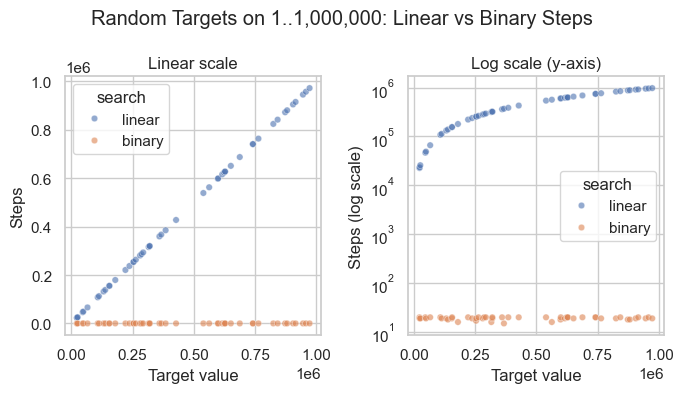

In [ ]:
# Random targets on one large dataset: 1 .. 1,000,000
import random
# %pip install pandas seaborn matplotlib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

N = 1_000_000
arr = list(range(1, N + 1))
rows = []
targets = sorted(random.sample(arr, 50))    # sort for cleaner left-to-right plot ordering

for target in targets:
    linear_steps = target  # in sorted 1..N, linear search finds target in `target` steps
    _, binary_steps = binary_search(arr, target)

    rows.append({"target": target, "search": "linear", "steps": linear_steps})
    rows.append({"target": target, "search": "binary", "steps": binary_steps})

df_random = pd.DataFrame(rows).sort_values("target")
binary_only = df_random.loc[df_random["search"] == "binary", "steps"]
print(f"binary_search step range: {binary_only.min()} to {binary_only.max()}; real max {math.log2(N):.2f}")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(7, 4))

# Left: linear scale — shows dramatic gap between O(n) and O(log n)
sns.scatterplot(data=df_random, x="target", y="steps", hue="search",
                alpha=0.6, s=22, ax=axes[0])
axes[0].set_title("Linear scale")
axes[0].set_xlabel("Target value")
axes[0].set_ylabel("Steps")
axes[0].legend(title="search")

# Right: log scale — makes binary search steps visible
sns.scatterplot(data=df_random, x="target", y="steps", hue="search",
                alpha=0.6, s=22, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Log scale (y-axis)")
axes[1].set_xlabel("Target value")
axes[1].set_ylabel("Steps (log scale)")
axes[1].legend(title="search")

plt.suptitle("Random Targets on 1..1,000,000: Linear vs Binary Steps")
plt.tight_layout()
plt.show()

To restate the power of binary search: to add one step in binary search, you need to double $n$; to double the number of steps, you need to **square** $n$.

| n | O(n) guesses | O(log₂n) guesses | O(n) / O(log₂n) |
|--:|--:|--:|--:|
| 4 | 4 | 2 | 2× |
| 8 | 8 | 3 | 3× |
| 10 | 10 | 4 | 3× |
| 16 | 16 | 4 | 4× |
| 32 | 32 | 5 | 6× |
| 64 | 64 | 6 | 11× |
| 100 | 100 | 7 | 14× |
| 1,000 | 1,000 | 10 | 100× |
| **1,000,000** | 1,000,000 | 20 | **50,000×** |
| 1,000,000,000 | 1,000,000,000 | 30 | 33,333,333× |


The theoretical values for the table above. 

In [17]:
import math

nums = [10, 100, 1000, 1_000_000, 1_000_000_000]
w = len(f"{max(nums):,}")

for n in nums:
    linear = n
    binary = math.log2(n)   ### binary search steps grow as log2(n)
    ratio = n / binary
    print(f"n={n:{w},}  linear={linear:{w},}  binary={binary:6.1f}  ratio={ratio:>{w},.0f}x")

n=           10  linear=           10  binary=   3.3  ratio=            3x
n=          100  linear=          100  binary=   6.6  ratio=           15x
n=        1,000  linear=        1,000  binary=  10.0  ratio=          100x
n=    1,000,000  linear=    1,000,000  binary=  19.9  ratio=       50,172x
n=1,000,000,000  linear=1,000,000,000  binary=  29.9  ratio=   33,447,777x


For our examples here, use `random.choice` to help us compare linear and binary search. Run the following code several times, and you may see and feel the difference between binary and linear search results.

In [18]:
import time
import random

arr = list(range(1_000_000))
target = random.choice(arr)

start = time.time()
idx = linear_search(arr, target)
linear_time = time.time() - start
print(f"Linear search for {target} → index {idx}  |  {linear_time:.6f} s")

start = time.time()
idx = binary_search(arr, target)
binary_time = time.time() - start
print(f"Binary search for {target} → index {idx}  |  {binary_time:.6f} s")

print(f"Binary search was {linear_time / binary_time:.1f}x faster")

Linear search for 681194 → index (681195, 681195)  |  0.027301 s
Binary search for 681194 → index (681195, 19)  |  0.000027 s
Binary search was 1013.3x faster


In [ ]:
### Exercise: Binary Search Implementation
#   1. What is the Big O complexity of the function below?
#      def count_evens(nums):
#          return [n for n in nums if n % 2 == 0]
#   2. Write a function `contains(arr, target)` that uses binary search
#      (O(log n)) to check whether target is in a SORTED array.
#   3. Test with: contains([1, 3, 5, 7, 9], 5)  -> True
#                 contains([1, 3, 5, 7, 9], 4)  -> False
### Your code starts here.



### Your code ends here.

In [ ]:
### Solution
# 1. count_evens is O(n) -- it visits every element once.

# 2. Binary search -- O(log n)
def contains(arr, target):
    low, high = 0, len(arr) - 1
    while low <= high:
        mid = (low + high) // 2
        if arr[mid] == target:
            return True
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return False

print(contains([1, 3, 5, 7, 9], 5))   # Expected: True
print(contains([1, 3, 5, 7, 9], 4))   # Expected: False

## Benchmarking

**Benchmarking** measures how long your code actually takes to run. It complements Big O analysis: Big O tells you the *shape* of growth asymptotically, while benchmarking gives you concrete runtimes on real hardware with real data. Together they answer both "will this scale?" and "is this fast enough today?"

Python provides three main tools for timing code, each suited to a different level of precision:

- **`time.time()`**: Returns wall-clock time as a float (seconds since the Unix epoch). Acceptable for rough, one-off prints where precision doesn't matter, but it can be skewed by OS clock corrections.

- **`time.perf_counter()`**: Returns a high-resolution performance counter with sub-microsecond precision. It is unaffected by OS clock changes, making it the preferred choice for timing short code blocks in instrumented scripts.

- **`timeit.timeit()` / `timeit.repeat()`**: The right tool for microbenchmarking a single expression or small snippet. It disables garbage collection between runs to reduce noise, executes the code many times to average out fluctuations, and manages multiple trials automatically. Use this when you need a repeatable, statistically meaningful measurement of a specific line or expression.

| Function | Module | Resolution | Use For | Notes |
|---|---|---|---|---|
| `time.time()` | `time` | Low (~10ms) | Timestamps, logging, wall-clock elapsed | Can go backward if system clock adjusted |
| `time.perf_counter()` | `time` | Very high (ns) | Benchmarking code blocks | Best for measuring elapsed time; never goes backward |
| `timeit.timeit()` | `timeit` | Very high (ns) | Microbenchmarks — single expression or function | Runs `number` times, returns total; divide for per-call avg |
| `timeit.repeat()` | `timeit` | Very high (ns) | Microbenchmarks across multiple trials | Returns list of times; use `min()` to report best trial |

The code below illustrates how the Big $O$ growth classes behave across different input sizes, so you can build intuition before profiling real algorithms.

In [19]:
import time
import timeit

data = list(range(100_000))

### --- time.time() --- for timestamps, logging,
# Coarse wall-clock timing; fine for quick prints, not precision work.
start = time.time()
max(data)
end = time.time()
print(f"time.time()        : {end - start:.6f} s")

### --- time.perf_counter() --- for benchmarking code performance.
# High-resolution counter; preferred for timing instrumented code blocks.
start = time.perf_counter()
max(data)
elapsed = time.perf_counter() - start
print(f"perf_counter()     : {elapsed:.6f} s")

### --- timeit.timeit() ---
# Runs the snippet many times and returns total time; best for microbenchmarks.
t = timeit.timeit(lambda: max(data), number=1_000)
print(f"timeit (1000 runs) : {t:.4f} s total  |  {t/1000*1e6:.2f} µs per call")

### --- timeit.repeat() ---
# Like timeit() but returns a list of times across multiple trials; use min() to report.
trials = timeit.repeat(lambda: max(data), repeat=5, number=200)
print(f"timeit.repeat()    : best of 5 trials = {min(trials)/200*1e6:.2f} µs per call")

time.time()        : 0.000565 s
perf_counter()     : 0.000592 s
timeit (1000 runs) : 0.5721 s total  |  572.10 µs per call
timeit.repeat()    : best of 5 trials = 567.49 µs per call


:::{admonition} Why Use `lambda` with `timeit`?

Lambda functions are used here to defer the execution of `max(data)` until `timeit` calls it. 
If we had written 
```
timeit.timeit(max(data), number=1000)
```
then `max(data)` runs once immediately and returns a number (e.g. 99999). Then `timeit` tries to call 99999 1000 times — which crashes. The lambda wraps it into a zero-argument function that timeit can call over and over:

```
t = timeit.timeit(lambda: max(data), number=1_000)
#                 ^^^^^^
#                 callable — timeit calls this 1000 times
#                 each call runs max(data) fresh
```

This is the same as:

```
def run():
    return max(data)

t = timeit.timeit(run, number=1_000)   # same thing, no lambda
```

The lambda is just a compact way to write that one-liner inline. The pattern `lambda: <expression>` is the standard idiom for "wrap this expression so it can be called later."
:::

Of course you would think that, in binary search, you would have to sort the array first, and you would be right. That should be part of the considerations when designing your algorithm. 

In [ ]:
### Exercise: Benchmark List vs. Set Membership
#   1. Create a list `data` with integers 0 to 99,999.
#   2. Create a set `data_set` from the same values.
#   3. Use timeit to measure 1000 lookups of 99999 in each.
#   4. Print both times and state which is faster.
### Your code starts here.



### Your code ends here.

In [ ]:
### Solution
import timeit

data     = list(range(100_000))
data_set = set(data)

t_list = timeit.timeit(lambda: 99999 in data,     number=1000)
t_set  = timeit.timeit(lambda: 99999 in data_set, number=1000)

print(f'List lookup: {t_list:.4f}s')
print(f'Set  lookup: {t_set:.4f}s')
print(f'Set is ~{t_list / t_set:.0f}x faster')

## Algorithm Selection Guide

Use this table as a quick reference when choosing a strategy:

| Condition | Recommended Approach | Complexity |
|---|---|---|
| Unsorted data, few lookups | Linear search | $O(n)$ |
| Sorted data, repeated lookups | Binary search | $O(\log n)$ |
| Heavy membership checks on static data | `set`/`dict` lookup | $O(1)$ average |
| Nearly sorted input | Insertion sort | $O(n)$ best case |
| General-purpose sort | Merge sort / Python Timsort | $O(n \log n)$ |

In [ ]:
### Exercise: Choose the Right Algorithm
#   For each scenario, write (as a comment) the recommended approach
#   and its Big O complexity.
#   1. A sorted list of 1 million product IDs -- find a specific ID.
#   2. An unsorted list of 10 names -- find one name.
#   3. Repeated membership checks on a static collection of usernames.
#   4. A nearly sorted list of timestamps -- sort them.
### Your code starts here.



### Your code ends here.

In [ ]:
### Solution
# 1. Sorted, large list       -> Binary search       O(log n)
# 2. Unsorted, tiny list      -> Linear search       O(n)
# 3. Static membership checks -> set lookup          O(1) average
# 4. Nearly sorted input      -> Insertion sort      O(n) best case

# Demonstration of scenario 3:
members = {'alice', 'bob', 'charlie', 'dave'}
for user in ['alice', 'eve', 'bob']:
    status = 'member' if user in members else 'not a member'
    print(f'{user}: {status}')